# Import

In [434]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
from torch.fft import fftn

from tqdm import trange

import brighteyes_ism.simulation.PSF_sim as sim
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.analysis.APR_lib as apr

from skimage.filters import gaussian
import brighteyes_ism.simulation.Tubulin_sim as simTub

import scipy
from torch.fft import fftn, ifftn, ifftshift
from scipy.ndimage import shift

# Functions

In [435]:
def model(t, C, tau, T):
    offset = t[len(t)//2]
    modello = C * ( np.heaviside(t-offset, 1) + 1/(np.exp(T/tau) - 1) ) * np.exp((-t+offset)/tau) 
    return modello

def rectangular_IRF(t, dt):
    """
    Rectangular function:
    f(t) = 1/T for 0 <= t <= dt
           0   otherwise
    Works with scalar or NumPy array t.
    """
    t = np.asarray(t)
    offset = t[len(t)//2]
    return np.where((t >= offset-dt) & (t <= offset + dt), 1.0, 0.0)

def pad_tensor(x: torch.Tensor, pad_left: int, pad_right: int, dim: int, mode: str = "reflect"):
    """
    Pad a tensor along one dimension.

    Args:
        x (torch.Tensor): Input tensor to pad.
        pad_left (int): Number of elements to pad before the data along the specified dimension.
        pad_right (int): Number of elements to pad after the data along the specified dimension.
        dim (int): Dimension along which to pad.
        mode (str, optional): Padding mode. One of {"reflect", "replicate", "constant"}. Default is "reflect".

    Returns:
        torch.Tensor: Padded tensor with the same dtype and device as input.

    Raises:
        ValueError: If an unsupported padding mode is specified.
    """

    if pad_left == 0 and pad_right == 0:
        return x

    length = x.shape[dim]

    if mode == "reflect":
        left_idx = torch.arange(pad_left, 0, -1, device=x.device)
        right_idx = torch.arange(length - 2, length - pad_right - 2, -1, device=x.device)
    elif mode == "replicate":
        left_idx = torch.zeros(pad_left, dtype=torch.long, device=x.device)
        right_idx = torch.full((pad_right,), length - 1, dtype=torch.long, device=x.device)
    elif mode == "constant":
        pad_shape = list(x.shape)
        pad_shape[dim] = pad_left + pad_right
        constant_pad = torch.zeros(pad_shape, dtype=x.dtype, device=x.device)
        return torch.cat([constant_pad.narrow(dim, 0, pad_left),
                          x,
                          constant_pad.narrow(dim, pad_left, pad_right)], dim=dim)
    else:
        raise ValueError(f"Unsupported padding mode: {mode}")

    # Select slices
    pad_left_tensor = x.index_select(dim, left_idx)
    pad_right_tensor = x.index_select(dim, right_idx)

    return torch.cat([pad_left_tensor, x, pad_right_tensor], dim=dim)


def median_filter(x: torch.Tensor, window_size=3, dims=None, mode="reflect"):
    """
    Apply an N-dimensional median filter over user-specified dimensions.

    Args:
        x (torch.Tensor): Input tensor of any shape.
        window_size (int or list/tuple of ints, optional): Window size(s) for the filter. If int, same size for all dims. If list/tuple, must match len(dims). Default is 3.
        dims (list/tuple of ints, optional): Dimensions to filter along. If None, all dimensions are filtered. Default is None.
        mode (str, optional): Padding mode. One of {"reflect", "replicate", "constant"}. Default is "reflect".

    Returns:
        torch.Tensor: Median-filtered tensor of the same shape as x.

    Raises:
        ValueError: If window_size is not odd or does not match dims length.
    """

    if dims is None:
        dims = list(range(x.ndim))

    if isinstance(window_size, int):
        window_size = [window_size] * len(dims)
    elif len(window_size) != len(dims):
        raise ValueError("window_size must be scalar or match len(dims)")

    # check for odd values
    for w in window_size:
        if w % 2 == 0:
            raise ValueError(f"All window sizes must be odd, got {w}")

    out = x
    for d, w in zip(dims, window_size):
        pad_left = (w - 1) // 2
        pad_right = w // 2

        # Pad along dimension
        out = pad_tensor(out, pad_left, pad_right, d, mode=mode)

        # Unfold and compute median
        out = out.unfold(d, w, 1).median(dim=-1).values

    return out

def partial_convolution_fft(volume: torch.tensor, kernel: torch.tensor, dim1: str = 'ijk', dim2: str = 'jkl',
                        axis: str = 'jk', fourier: tuple = (False, False)):

    dim3 = dim1 + dim2
    dim3 = ''.join(sorted(set(dim3), key=dim3.index))

    dims = [dim1, dim2, dim3]

    axis_list = [[d.find(c) for c in axis] for d in dims]

    if fourier[0] == False:
        volume_fft = fftn(volume, dim=axis_list[0])
    else:
        volume_fft = volume

    if fourier[1] == False:
        kernel_fft = fftn(kernel, dim=axis_list[1])
    else:
        kernel_fft = kernel

    conv = torch.einsum(f'{dim1},{dim2}->{dim3}', volume_fft, kernel_fft)

    conv = ifftn(conv, dim=axis_list[2])  # inverse FFT of the product
    conv = ifftshift(conv, dim=axis_list[2])  # Rotation of 180 degrees of the phase of the FFT
    conv = torch.real(conv)  # Clipping to zero the residual imaginary part

    return conv

def richardson_lucy_deconvolution(ref_data, t, C_R, tau_R, T, iterations=30, eps=1e-8, regularization=3):
        """
        Perform Richardson-Lucy deconvolution channel-wise using FFT-based convolutions and a precomputed kernel.

        Args:
            ref_data (torch.Tensor): Reference data for deconvolution.
            iterations (int): Number of RL iterations (default: 30).
            eps (float): Small value to avoid division by zero (default: 1e-4).

        Side effects:
            Sets self.irf to the deconvolved estimate (shape: [num_samples, num_channels]).

        Raises:
            RuntimeError: If self.kernel is None.
        """
        
        
        # initialize output tensor
        irf_est = torch.ones_like(ref_data) # shape (time)

        # load deconvolution kernel
        kernel =  torch.tensor(model(t, C_R, tau_R, T))
        kernel_t = kernel.clone().flip(0)

        kernel = fftn(kernel, dim=0) # FT of kernel, shape (time,)
        kernel_t = fftn(kernel_t, dim=0)  # FT of time-reversed kernel, shape (time,)

        # Subtract offset
        y = torch.clamp(ref_data, min=0)

        # RL deconvolution
        for _ in range(iterations):
            conv = partial_convolution_fft(irf_est, kernel, dim1='t', dim2='t', axis='t', fourier=(0,1))
            conv = torch.clamp(conv, min=eps)  # avoid div by 0
            relative_blur = y / conv
            correction = partial_convolution_fft(relative_blur, kernel_t, dim1='t', dim2='t', axis='t', fourier=(0,1))
            irf_est = irf_est * correction
            irf_est = torch.clamp(irf_est, min=0)  # enforce positivity
            if regularization > 1:
                irf_est = median_filter(irf_est, window_size=regularization, dims=[0], mode='replicate')  # temporal median filter

        return irf_est

# Parameters

In [436]:
dt = 0.297619  # ns
nbin = 81
period = nbin * dt
t = np.arange(nbin)*dt
tau = 5
tau_R = 1.5
C = 1e3
C_R = 3e3
dT = 50*dt

In [437]:
irf = rectangular_IRF(t, 2*dt)
irf /= irf.sum()  # Normalize the IRF to have an area of 1

# Tests

In [438]:
ref_model = model(t, C_R, tau_R, period)
irf_shifted = shift(irf, dT, order=1, mode='grid-wrap')
ref_clean_data = partial_convolution_fft(torch.tensor(ref_model), torch.tensor(irf_shifted), dim1='t', dim2='t', axis='t', fourier=(0,0))
ref_data = np.random.poisson( ref_clean_data )  # Add Poisson noise and shift the data to simulate a delay
ref_data = ref_data / np.sum(ref_data)  # Normalize the reference data to have an area of 1

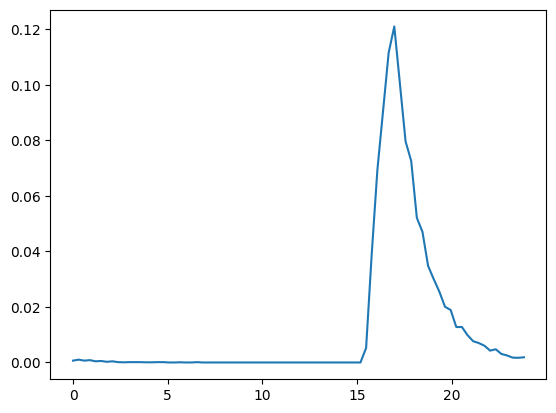

In [439]:
plt.plot(t, ref_data)

In [440]:
est_irf = richardson_lucy_deconvolution(torch.tensor(ref_data), t, C_R, tau_R, period, iterations=300)

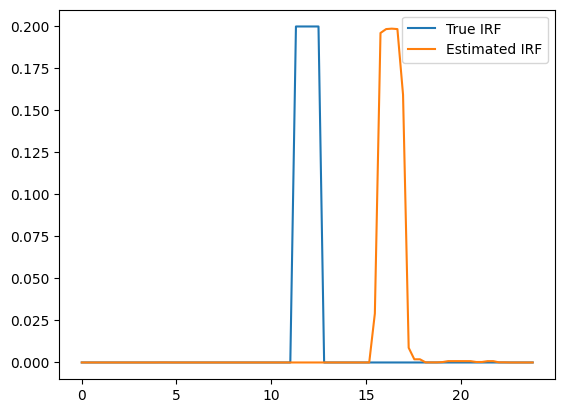

In [441]:
plt.plot(t, irf, label='True IRF')
plt.plot(t, est_irf, label='Estimated IRF')
plt.legend()

# Generate phantom data

In [442]:
pure_model = model(t, C, tau, period)
dato_clean = partial_convolution_fft(torch.tensor(pure_model), torch.tensor(irf), dim1='t', dim2='t', axis='t', fourier=(0,0))
dato = np.random.poisson(dato_clean)  # Add Poisson noise

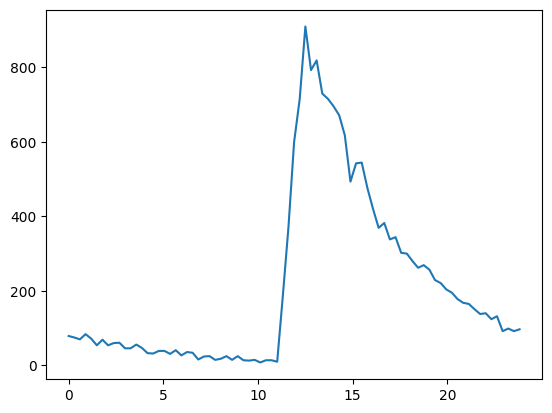

In [443]:
plt.plot(t, dato)

# Fit data

In [444]:
def fit_model(t, C, dT, tau, irf=est_irf, period=period):
    pure_model = model(t, C, tau, period)
    model_shifted = shift(pure_model, dT, order=1, mode='grid-wrap') #shift of corrected model
    data = partial_convolution_fft(torch.tensor(model_shifted), torch.tensor(irf), dim1='t', dim2='t', axis='t', fourier=(0,0))
    return data

In [445]:
popt, conv = scipy.optimize.curve_fit(
    fit_model, t, dato, p0=[10, 10, 1], bounds=([0, -nbin//2, 0.01], [np.inf, nbin//2, 10])
)
 
fitted_data = fit_model(t, *popt)

C:\Users\lcuneo\AppData\Local\Temp\ipykernel_29460\860571976.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = partial_convolution_fft(torch.tensor(model_shifted), torch.tensor(irf), dim1='t', dim2='t', axis='t', fourier=(0,0))


In [446]:
print(C, dT, tau)
print(popt)

1000.0 14.88095 5
[1014.68365513  -14.83429457    4.89330651]


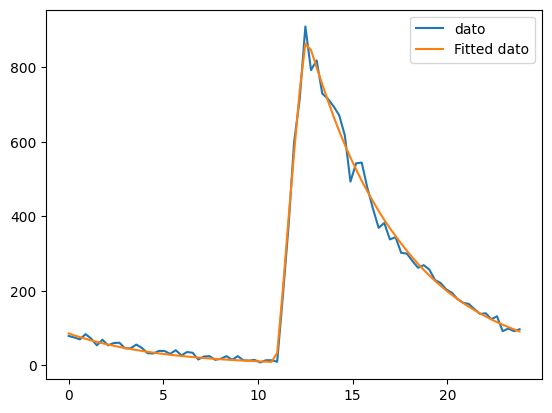

In [447]:
plt.plot(t, dato, label='dato')
plt.plot(t, fitted_data, label='Fitted dato')
plt.legend()